Task1

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

## Task 2

In [3]:
data = {
    "month": [
        "2023-01", "2023-02", "2023-03", "2023-04",
        "2023-05", "2023-06", "2023-07", "2023-08",
        "2023-09", "2023-10", "2023-11", "2023-12"
    ],
    "visits": [
        1200, 1350, 1100, 980,
        870, 760, 800, 950,
        1050, 1300, 1600, 1750
    ]
}

df_visits = pd.DataFrame(data)
df_visits["month"] = pd.to_datetime(df_visits["month"])

print(df_visits.dtypes)
print(df_visits.head())

month     datetime64[ns]
visits             int64
dtype: object
       month  visits
0 2023-01-01    1200
1 2023-02-01    1350
2 2023-03-01    1100
3 2023-04-01     980
4 2023-05-01     870


1. The month coloumn shows datetime after pd.to_datetime()  
2. It matters for manipulation of time ranges as well as plot spacing



## Task 3

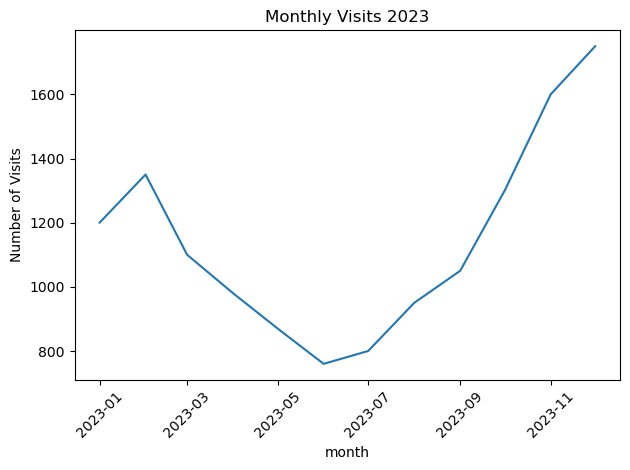

In [4]:

plt.plot(df_visits["month"], df_visits["visits"])
plt.title("Monthly Visits 2023")
plt.xlabel("month")
plt.ylabel("Number of Visits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 4

In [5]:
df_visits["mobile_visits"] = [
    500, 600, 480, 420,
    380, 310, 340, 400,
    460, 580, 720, 800
]

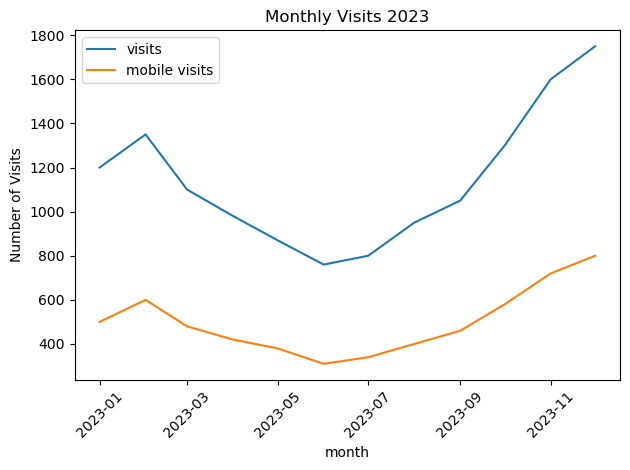

In [6]:

plt.plot(df_visits["month"], df_visits["visits"], label="visits")
plt.plot(df_visits["month"], df_visits["mobile_visits"], label="mobile visits")
plt.title("Monthly Visits 2023")
plt.xlabel("month")
plt.ylabel("Number of Visits")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Task 5

In [7]:
df_ag=pd.read_csv("2011_ag.csv")
df_ag.head()

,code,state,category,total exports,beef,pork,poultry,dairy,fruits fresh,fruits proc,total fruits,veggies fresh,veggies proc,total veggies,corn,wheat,cotton
0,AL,Alabama,state,1390.63,34.4,10.6,481.0,4.06,8.0,17.1,25.11,5.5,8.9,14.33,34.9,70.0,317.61
1,AK,Alaska,state,13.31,0.2,0.1,0.0,0.19,0.0,0.0,0.00,0.6,1.0,1.56,0.0,0.0,0.00
2,AZ,Arizona,state,1463.17,71.3,17.9,0.0,105.48,19.3,41.0,60.27,147.5,239.4,386.91,7.3,48.7,423.95
3,AR,Arkansas,state,3586.02,53.2,29.4,562.9,3.53,2.2,4.7,6.88,4.4,7.1,11.45,69.5,114.5,665.44
4,CA,California,state,16472.88,228.7,11.1,225.4,929.95,2791.8,5944.6,8736.40,803.2,1303.5,2106.79,34.6,249.3,1064.95


In [8]:
df_ag.shape

(50, 17)

In [9]:
df_ag.columns

Index(['code', 'state', 'category', 'total exports', 'beef', 'pork', 'poultry',
       'dairy', 'fruits fresh', 'fruits proc', 'total fruits', 'veggies fresh',
       'veggies proc', 'total veggies', 'corn', 'wheat', 'cotton'],
      dtype='object')

There are 50 states in the data set  
Each row is the various exports from each state  
The code column contains the state codes  


## Task 6

In [11]:
df_sorted = df_ag.sort_values("total exports", ascending=False)
df_sorted[['state', 'total exports']].head()

,state,total exports
4,California,16472.88
14,Iowa,11273.76
12,Illinois,8709.48
22,Minnesota,7192.33
26,Nebraska,7114.13


California had the highest total agricultural exports in 2011

## Task 7

In [25]:
fig = px.choropleth(data_frame=df_ag,
              locations='code',
              locationmode='USA-states',
              color='total exports',
              scope='usa',
              color_continuous_scale='Greens',
              hover_name='state'
              )
fig.update_layout(title = '2011 U.S. Agricultural Exports by State (Millions $)')
fig.show()

## Task 8

In [26]:
fig = px.choropleth(data_frame=df_ag,
              locations='code',
              locationmode='USA-states',
              color='total exports',
              scope='usa',
              color_continuous_scale='YlOrRd',
              hover_name='state'
              )
fig.update_layout(title = '2011 U.S. Agricultural Exports by State (Millions $)')
fig.show()

1. Instead of using a gradient of a single color, certain colors correspond with higher amounts
2. They are both good, but yellow red pops more

## Task 9

In [27]:
cities = {
    "city": [
        "Fresno", "Des Moines", "Lubbock",
        "Yakima", "Bakersfield", "Salinas"
    ],
    "lat": [36.7, 41.6, 33.6, 46.6, 35.4, 36.7],
    "lon": [-119.8, -93.6, -101.8, -120.5, -119.0, -121.7],
    "export_value": [4200, 3100, 2800, 2200, 3900, 1800]
}

df_cities = pd.DataFrame(cities)

In [32]:
fig = px.scatter_geo(data_frame=df_cities,
                     lat='lat',
                     lon='lon',
                     size='export_value',
                     color='export_value',
                     hover_name='city',
                     scope='usa')
fig.update_layout(title={'text':'Agricultural Export Value by City (Thousands $)', 'x':0.5})

In [38]:
fig = px.scatter_geo(data_frame=df_cities,
                     lat='lat',
                     lon='lon',
                     size='export_value',
                     color='export_value',
                     hover_name='city',
                     scope='usa',
                     labels={'export_value': 'Exports (Thousands $)'})
fig.update_layout(title={'text':'Agricultural Export Value by City (Thousands $)', 'x':0.5})
fig.show()

## Task 11

In [39]:
fig = px.choropleth(data_frame=df_ag,
              locations='code',
              locationmode='USA-states',
              color='corn',
              scope='usa',
              color_continuous_scale='Greens',
              hover_name='state'
              )
fig.update_layout(title={'text':'Corn Export Value by State (Millions $)', 'x':0.5})

The midwest dominates corn exports, which makes sense as Nebraska has a lot of corn.